# Case Study 3: E-commerce Landing Page Test — Data Quality Gate Demo

**Data:** REAL website A/B test dataset (294,478 rows), widely used in
"Analyze A/B Test Results"-style projects. Users saw either `old_page`
(control) or `new_page` (treatment); `converted` is a binary purchase/signup
flag.

**Why this case study is here:** this dataset contains a REAL logging bug —
3,893 rows where the group label and the page actually shown don't match —
while the raw group **sizes** still pass a standard SRM check almost
perfectly (50.01% vs. 50.00%). This is the clearest demonstration in this
portfolio that **SRM checks catch allocation-size problems, not per-unit
contamination** — a second, unit-level integrity check is needed and is
often skipped in portfolios that only check SRM.


In [1]:
import sys
sys.path.append('../../../shared')
import pandas as pd
import matplotlib.pyplot as plt
from stats_toolkit import srm_check_counts, two_proportion_ztest

plt.rcParams['figure.figsize'] = (8, 4)
df = pd.read_csv('../ab_data.csv', parse_dates=['timestamp'])
print(f"Raw rows: {len(df):,}")
df.head()


Raw rows: 294,478


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## 1. Standard SRM check on raw group sizes — looks fine

In [2]:
srm_raw = srm_check_counts((df.group == 'control').sum(), (df.group == 'treatment').sum())
srm_raw


{'n_control': 147202,
 'n_treatment': 147276,
 'observed_ratio_treatment': np.float64(0.50013),
 'expected_ratio_treatment': 0.5,
 'chi2_statistic': np.float64(0.0186),
 'p_value': np.float64(0.8915321515063552),
 'srm_detected': np.False_,
 'threshold': 0.001}

In [3]:
print(f"Observed split: {srm_raw['observed_ratio_treatment']*100:.2f}% treatment "
      f"vs. expected 50.00% — p={srm_raw['p_value']:.3f}. Passes comfortably.")
print("If we stopped here, we'd conclude the data is clean. It isn't.")


Observed split: 50.01% treatment vs. expected 50.00% — p=0.892. Passes comfortably.
If we stopped here, we'd conclude the data is clean. It isn't.


## 2. Unit-of-analysis integrity check — this is where the real problem shows up

Each user should see exactly one page, matching their assigned group. Let's check.


In [4]:
mismatch_mask = (
    ((df.group == 'control') & (df.landing_page == 'new_page')) |
    ((df.group == 'treatment') & (df.landing_page == 'old_page'))
)
n_mismatched = mismatch_mask.sum()
n_dupe_rows = df.user_id.duplicated(keep=False).sum()

print(f"Rows where group label and page shown DON'T match: {n_mismatched:,} "
      f"({100*n_mismatched/len(df):.2f}% of all rows)")
print(f"Rows involved in a duplicated user_id: {n_dupe_rows:,}")


Rows where group label and page shown DON'T match: 3,893 (1.32% of all rows)
Rows involved in a duplicated user_id: 7,788


In [5]:
df[mismatch_mask].head(6)


,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0
490,808613,2017-01-10 21:44:01.292755,control,new_page,0


**This is a real assignment/logging bug** — likely some users got bucketed
into the experiment more than once (e.g. clearing cookies, multiple devices)
and landed in both arms, or a server-side routing bug occasionally served
the wrong page for the logged group. Whatever the cause, these rows cannot
be trusted for a per-user causal comparison, even though the *aggregate*
group sizes look perfectly balanced.


## 3. Data cleaning decision — made BEFORE looking at the outcome

To avoid any appearance of cherry-picking rows that support a particular
conclusion, the cleaning rule here is based purely on assignment integrity,
decided before computing any conversion rates:
1. Drop all rows with a group/page mismatch
2. Of the remaining rows, drop any repeated `user_id` (keep first occurrence)


In [6]:
clean = df[~mismatch_mask].drop_duplicates(subset='user_id', keep='first')
print(f"Rows dropped: {len(df) - len(clean):,} ({100*(len(df)-len(clean))/len(df):.2f}% of raw data)")
print(f"Clean dataset: {len(clean):,} rows")

srm_clean = srm_check_counts((clean.group == 'control').sum(), (clean.group == 'treatment').sum())
print("\nSRM re-check after cleaning:", srm_clean)


Rows dropped: 3,894 (1.32% of raw data)
Clean dataset: 290,584 rows



SRM re-check after cleaning: {'n_control': 145274, 'n_treatment': 145310, 'observed_ratio_treatment': np.float64(0.50006), 'expected_ratio_treatment': 0.5, 'chi2_statistic': np.float64(0.0045), 'p_value': np.float64(0.9467543681597944), 'srm_detected': np.False_, 'threshold': 0.001}


## 4. Primary metric: conversion rate

Single pre-specified primary metric. No guardrails are available in this
dataset — no revenue, refund, or support-contact fields were collected.
That's a real limitation, documented here rather than fabricated.


In [7]:
t = clean[clean.group == 'treatment']
c = clean[clean.group == 'control']
primary = two_proportion_ztest(t.converted.sum(), len(t), c.converted.sum(), len(c),
                                'conversion_rate_primary')
primary


{'metric': 'conversion_rate_primary',
 'rate_treatment': np.float64(0.11881),
 'rate_control': np.float64(0.12039),
 'absolute_diff': np.float64(-0.00158),
 'relative_diff_pct': np.float64(-1.311),
 'ci_95_absolute': [np.float64(-0.00394), np.float64(0.00078)],
 'z_stat': np.float64(-1.3109),
 'p_value': np.float64(0.18988337448195103)}

## 5. Novelty check across the 22-day window

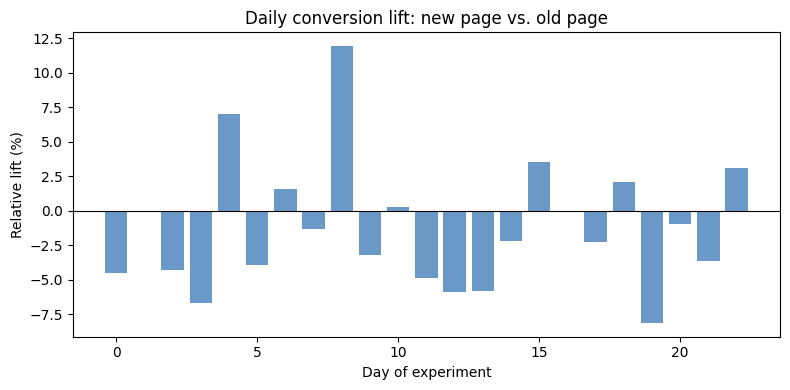

Lift bounces both directions with no clear trend — consistent with pure noise around a true effect close to zero, not a fading/growing pattern.


In [8]:
clean = clean.copy()
clean['day'] = clean['timestamp'].dt.date
daily = clean.groupby(['day', 'group'])['converted'].mean().unstack()
daily['rel_lift'] = (daily['treatment'] - daily['control']) / daily['control']

fig, ax = plt.subplots()
ax.bar(range(len(daily)), daily['rel_lift']*100, color='#2b6cb0', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Day of experiment')
ax.set_ylabel('Relative lift (%)')
ax.set_title('Daily conversion lift: new page vs. old page')
plt.tight_layout()
plt.savefig('../reports/daily_lift.png', dpi=140)
plt.show()
print("Lift bounces both directions with no clear trend — consistent with pure noise "
      "around a true effect close to zero, not a fading/growing pattern.")


## 6. Visualizing the primary result

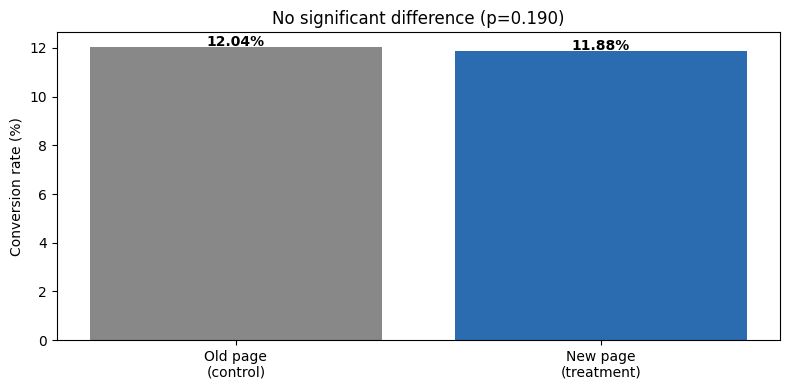

In [9]:
fig, ax = plt.subplots()
rates = [primary['rate_control']*100, primary['rate_treatment']*100]
bars = ax.bar(['Old page\n(control)', 'New page\n(treatment)'], rates, color=['#888888', '#2b6cb0'])
for b, r in zip(bars, rates):
    ax.text(b.get_x()+b.get_width()/2, r+0.05, f'{r:.2f}%', ha='center', fontweight='bold')
ax.set_ylabel('Conversion rate (%)')
ax.set_title(f"No significant difference (p={primary['p_value']:.3f})")
plt.tight_layout()
plt.savefig('../reports/conversion_comparison.png', dpi=140)
plt.show()


## 7. Decision

In [10]:
is_significant_positive = primary['p_value'] < 0.05 and primary['absolute_diff'] > 0
print("Statistically significant improvement?", is_significant_positive)
if not is_significant_positive:
    print("\nDECISION: DO NOT SHIP — keep the old page")
    print(f"Conversion rate difference is not significant (p={primary['p_value']:.3f}), "
          f"and the point estimate is actually slightly negative for the new page "
          f"({primary['relative_diff_pct']}% relative).")


Statistically significant improvement? False

DECISION: DO NOT SHIP — keep the old page
Conversion rate difference is not significant (p=0.190), and the point estimate is actually slightly negative for the new page (-1.311% relative).


## 8. Conclusion

Two separate findings here, both important:

1. **Data quality**: a real assignment-integrity bug affected 1.32% of rows.
   The raw group *sizes* passed a standard SRM check almost perfectly
   (p=0.89) — proof that SRM alone is not a sufficient data-quality gate.
   A second, unit-level check (does each user's assigned group match what
   they actually saw?) caught a problem SRM missed entirely.

2. **Primary result**: after cleaning, the new page does **not** produce a
   statistically significant improvement in conversion (11.88% vs. 12.04%,
   p=0.19), and the point estimate is actually slightly negative. The daily
   lift series shows no clear trend, consistent with noise around a
   near-zero true effect.

**Recommendation: do not ship the new landing page.** There's no evidence it
improves conversion, and no guardrail data exists to argue for it on other
grounds. This matches the real, widely-cited conclusion for this dataset.
